<center><h1> Retail Demand Forescasting of TimeSeries Data Using XGBOOST </h1> </center>

## Objective
- This project explores time-series forecasting for the Corporación Favorita dataset.
- The primary focus is on predicting daily sales using Tree based model XGBOOST and to understand the underlying data patterns.

## Importing libraries

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import xgboost as xgb
from sklearn.metrics import mean_squared_log_error

## Loading Dataset

In [110]:
train = pd.read_csv('/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv')
test = pd.read_csv('/kaggle/input/competitions/store-sales-time-series-forecasting/test.csv')
stores = pd.read_csv('/kaggle/input/competitions/store-sales-time-series-forecasting/stores.csv')
oil = pd.read_csv('/kaggle/input/competitions/store-sales-time-series-forecasting/oil.csv')
holidays = pd.read_csv('/kaggle/input/competitions/store-sales-time-series-forecasting/holidays_events.csv')

## Data Analysis

In [111]:
print("Training data:",train.shape)
print("Testing data:",test.shape)
print("Sample train data")
train.head()

Training data: (3000888, 6)
Testing data: (28512, 5)
Sample train data


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [112]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


## Converting date column to type Date

In [113]:
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           28512 non-null  int64         
 1   date         28512 non-null  datetime64[ns]
 2   store_nbr    28512 non-null  int64         
 3   family       28512 non-null  object        
 4   onpromotion  28512 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 1.1+ MB


In [114]:
print("Number of stores in the dataset:",train['store_nbr'].nunique())

Number of stores in the dataset: 54


In [115]:
train.describe()

,id,date,store_nbr,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2015-04-24 08:27:04.703088384,2.750000e+01,3.577757e+02,2.602770e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02
std,8.662819e+05,NaN,1.558579e+01,1.101998e+03,1.221888e+01


In [116]:
test.describe()

,id,date,store_nbr,onpromotion
count,2.851200e+04,28512,28512.000000,28512.000000
mean,3.015144e+06,2017-08-23 12:00:00,27.500000,6.965383
min,3.000888e+06,2017-08-16 00:00:00,1.000000,0.000000
25%,3.008016e+06,2017-08-19 18:00:00,14.000000,0.000000
50%,3.015144e+06,2017-08-23 12:00:00,27.500000,0.000000
75%,3.022271e+06,2017-08-27 06:00:00,41.000000,6.000000
max,3.029399e+06,2017-08-31 00:00:00,54.000000,646.000000
std,8.230850e+03,NaN,15.586057,20.683952


## Merging the train and test with data Stores data (On store number)

In [117]:
print("Stores data:",stores.shape)
stores.head()

Stores data: (54, 5)


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [118]:
train_mrgd_sto = train.merge(stores, on='store_nbr', how='left')
test_mrgd_sto = test.merge(stores, on='store_nbr', how='left')
train_mrgd_sto.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13


## Merging the train and test with Oil Price data (On date)

In [119]:
print("Oil data:",oil.shape)
oil.head()

Oil data: (1218, 2)


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [120]:
oil['date'] = pd.to_datetime(oil['date'])
train_mrgd_sto_oil = train_mrgd_sto.merge(oil, on='date', how='left')
test_mrgd_sto_oil = test_mrgd_sto.merge(oil, on='date', how='left')
train_mrgd_sto_oil.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,NaN
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,NaN
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,NaN


## Handling the missing values for the oil price

In [121]:
# Forward fill handles the holidays (Previous day price for martin luther king day(jan 21),president's day feb 18th)
# Backward fill handles the first day (Jan 1) by using Jan 2's price
train_mrgd_sto_oil['dcoilwtico'] = train_mrgd_sto_oil['dcoilwtico'].ffill().bfill()
test_mrgd_sto_oil['dcoilwtico'] = test_mrgd_sto_oil['dcoilwtico'].ffill().bfill()
print("Null in training data",train_mrgd_sto_oil.isnull().sum())
print("Null in test data",test_mrgd_sto_oil.isnull().sum())

Null in training data id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
city           0
state          0
type           0
cluster        0
dcoilwtico     0
dtype: int64
Null in test data id             0
date           0
store_nbr      0
family         0
onpromotion    0
city           0
state          0
type           0
cluster        0
dcoilwtico     0
dtype: int64


## Merging the train and test with data Holiday data (On date)

In [122]:
print("Holiday data:",holidays.shape)
holidays.head()

Holiday data: (350, 6)


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [123]:
holidays['date'] = pd.to_datetime(holidays['date'])

# Keeping only holidays that actually occurred on that date
real_holidays = holidays[holidays['transferred'] == False]

# If two holidays happen on one day, we can keep one 
real_holidays = real_holidays.drop_duplicates(subset=['date'])

# Merging with train & test data
train_mrgd_sto_oil_hol = train_mrgd_sto_oil.merge(real_holidays[['date', 'type', 'locale', 'locale_name']], 
                           on='date', 
                           how='left')
test_mrgd_sto_oil_hol = test_mrgd_sto_oil.merge(real_holidays[['date', 'type', 'locale', 'locale_name']], 
                           on='date', 
                           how='left')
train_mrgd_sto_oil_hol.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,dcoilwtico,type_y,locale,locale_name
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,National,Ecuador
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,National,Ecuador
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,National,Ecuador
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,National,Ecuador
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,93.14,Holiday,National,Ecuador


### Renaming the columns type_x, type_y and family

In [124]:
train_mrgd_sto_oil_hol.rename(columns={'type_x':'store_type','type_y':'holiday_type','family':'prod_category'},inplace=True)
test_mrgd_sto_oil_hol.rename(columns={'type_x':'store_type','type_y':'holiday_type','family':'prod_category'},inplace=True)
test_mrgd_sto_oil_hol.head()

,id,date,store_nbr,prod_category,onpromotion,city,state,store_type,cluster,dcoilwtico,holiday_type,locale,locale_name
0,3000888,2017-08-16,1,AUTOMOTIVE,0,Quito,Pichincha,D,13,46.8,NaN,NaN,NaN
1,3000889,2017-08-16,1,BABY CARE,0,Quito,Pichincha,D,13,46.8,NaN,NaN,NaN
2,3000890,2017-08-16,1,BEAUTY,2,Quito,Pichincha,D,13,46.8,NaN,NaN,NaN
3,3000891,2017-08-16,1,BEVERAGES,20,Quito,Pichincha,D,13,46.8,NaN,NaN,NaN
4,3000892,2017-08-16,1,BOOKS,0,Quito,Pichincha,D,13,46.8,NaN,NaN,NaN


## Handling NULL holiday columns in train and test - replaced with 'Workday'

In [125]:
holiday_cols = ['holiday_type', 'locale', 'locale_name']

for col in holiday_cols:
    train_mrgd_sto_oil_hol[col] = train_mrgd_sto_oil_hol[col].fillna('Workday')
    test_mrgd_sto_oil_hol[col] = test_mrgd_sto_oil_hol[col].fillna('Workday')
test_mrgd_sto_oil_hol.head()

,id,date,store_nbr,prod_category,onpromotion,city,state,store_type,cluster,dcoilwtico,holiday_type,locale,locale_name
0,3000888,2017-08-16,1,AUTOMOTIVE,0,Quito,Pichincha,D,13,46.8,Workday,Workday,Workday
1,3000889,2017-08-16,1,BABY CARE,0,Quito,Pichincha,D,13,46.8,Workday,Workday,Workday
2,3000890,2017-08-16,1,BEAUTY,2,Quito,Pichincha,D,13,46.8,Workday,Workday,Workday
3,3000891,2017-08-16,1,BEVERAGES,20,Quito,Pichincha,D,13,46.8,Workday,Workday,Workday
4,3000892,2017-08-16,1,BOOKS,0,Quito,Pichincha,D,13,46.8,Workday,Workday,Workday


In [126]:
test_mrgd_sto_oil_hol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             28512 non-null  int64         
 1   date           28512 non-null  datetime64[ns]
 2   store_nbr      28512 non-null  int64         
 3   prod_category  28512 non-null  object        
 4   onpromotion    28512 non-null  int64         
 5   city           28512 non-null  object        
 6   state          28512 non-null  object        
 7   store_type     28512 non-null  object        
 8   cluster        28512 non-null  int64         
 9   dcoilwtico     28512 non-null  float64       
 10  holiday_type   28512 non-null  object        
 11  locale         28512 non-null  object        
 12  locale_name    28512 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(7)
memory usage: 2.8+ MB


## Extracting info about date from date column

In [127]:
train_mrgd_sto_oil_hol['year'] = train_mrgd_sto_oil_hol['date'].dt.year
train_mrgd_sto_oil_hol['month'] = train_mrgd_sto_oil_hol['date'].dt.month
train_mrgd_sto_oil_hol['day'] = train_mrgd_sto_oil_hol['date'].dt.day
train_mrgd_sto_oil_hol['day_of_week'] = train_mrgd_sto_oil_hol['date'].dt.dayofweek  # Monday=0, Sunday=6
train_mrgd_sto_oil_hol['is_weekend'] = (train_mrgd_sto_oil_hol['day_of_week'] >= 5).astype(int)

test_mrgd_sto_oil_hol['year'] = test_mrgd_sto_oil_hol['date'].dt.year
test_mrgd_sto_oil_hol['month'] = test_mrgd_sto_oil_hol['date'].dt.month
test_mrgd_sto_oil_hol['day'] = test_mrgd_sto_oil_hol['date'].dt.day
test_mrgd_sto_oil_hol['day_of_week'] = test_mrgd_sto_oil_hol['date'].dt.dayofweek  # Monday=0, Sunday=6
test_mrgd_sto_oil_hol['is_weekend'] = (test_mrgd_sto_oil_hol['day_of_week'] >= 5).astype(int)
test_mrgd_sto_oil_hol.head()

,id,date,store_nbr,prod_category,onpromotion,city,state,store_type,cluster,dcoilwtico,holiday_type,locale,locale_name,year,month,day,day_of_week,is_weekend
0,3000888,2017-08-16,1,AUTOMOTIVE,0,Quito,Pichincha,D,13,46.8,Workday,Workday,Workday,2017,8,16,2,0
1,3000889,2017-08-16,1,BABY CARE,0,Quito,Pichincha,D,13,46.8,Workday,Workday,Workday,2017,8,16,2,0
2,3000890,2017-08-16,1,BEAUTY,2,Quito,Pichincha,D,13,46.8,Workday,Workday,Workday,2017,8,16,2,0
3,3000891,2017-08-16,1,BEVERAGES,20,Quito,Pichincha,D,13,46.8,Workday,Workday,Workday,2017,8,16,2,0
4,3000892,2017-08-16,1,BOOKS,0,Quito,Pichincha,D,13,46.8,Workday,Workday,Workday,2017,8,16,2,0


## Adding lag_features to train and test data

In [128]:

def add_lags(df, lags=[16, 21, 28]): # Instead of 1,7, 14 because test data doesn't have previous day or previous 7 day 
    # or previous 14 day sales data for most of its records. Hence we can shift by 16,21 and 28 
    df = df.sort_values(['store_nbr', 'prod_category', 'date'])
    
    for lag in lags:
        df[f'sales_lag_{lag}'] = (
            df.groupby(['store_nbr', 'prod_category'],observed=True)['sales']
              .shift(lag)
        )
        
    return df

# Combining first for test lag continuity
full_data = pd.concat([train_mrgd_sto_oil_hol, test_mrgd_sto_oil_hol])

# Adding lag features
full_data = add_lags(full_data, lags=[16, 21, 28])

# Split back
train_with_lags = full_data[full_data['date'] < '2017-08-16'].copy()
test_with_lags = full_data[full_data['date'] >= '2017-08-16'].copy()


In [129]:
train_with_lags.head()

,id,date,store_nbr,prod_category,sales,onpromotion,city,state,store_type,cluster,...,locale,locale_name,year,month,day,day_of_week,is_weekend,sales_lag_16,sales_lag_21,sales_lag_28
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,...,National,Ecuador,2013,1,1,1,0,NaN,NaN,NaN
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0,Quito,Pichincha,D,13,...,Workday,Workday,2013,1,2,2,0,NaN,NaN,NaN
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0,Quito,Pichincha,D,13,...,Workday,Workday,2013,1,3,3,0,NaN,NaN,NaN
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0,Quito,Pichincha,D,13,...,Workday,Workday,2013,1,4,4,0,NaN,NaN,NaN
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0,Quito,Pichincha,D,13,...,National,Ecuador,2013,1,5,5,1,NaN,NaN,NaN


In [130]:
test_with_lags.head()

,id,date,store_nbr,prod_category,sales,onpromotion,city,state,store_type,cluster,...,locale,locale_name,year,month,day,day_of_week,is_weekend,sales_lag_16,sales_lag_21,sales_lag_28
0,3000888,2017-08-16,1,AUTOMOTIVE,NaN,0,Quito,Pichincha,D,13,...,Workday,Workday,2017,8,16,2,0,8.0,2.0,7.0
1782,3002670,2017-08-17,1,AUTOMOTIVE,NaN,0,Quito,Pichincha,D,13,...,Workday,Workday,2017,8,17,3,0,5.0,5.0,4.0
3564,3004452,2017-08-18,1,AUTOMOTIVE,NaN,0,Quito,Pichincha,D,13,...,Workday,Workday,2017,8,18,4,0,4.0,7.0,10.0
5346,3006234,2017-08-19,1,AUTOMOTIVE,NaN,0,Quito,Pichincha,D,13,...,Workday,Workday,2017,8,19,5,1,3.0,4.0,8.0
7128,3008016,2017-08-20,1,AUTOMOTIVE,NaN,0,Quito,Pichincha,D,13,...,Workday,Workday,2017,8,20,6,1,8.0,1.0,0.0


## Adding the feature 'rolling mean' to train and test data

In [131]:
def add_rolling_features(df):
    df = df.sort_values(['store_nbr', 'prod_category', 'date'])
    
    for window in [7, 14, 30]:
        # We calculate the mean over the window
        # We use .shift(1) first to ensure we aren't including 'today' in the average to prevent leakage
        #df[f'rolling_mean_{window}'] = df.groupby(['store_nbr', 'prod_category'])['sales'].transform(
            #lambda x: x.shift(1).rolling(window=window).mean())
        # In the test data when we try to predict for August 31st, when computing the rolling_mean when we shift by one 
        # row we don't have sales data August 30th or the previous 7 days, so when we shift by 16, we can lookup the sales on Aug 15th 
        # the last day of training data.
        df[f'rolling_mean_{window}'] = df.groupby(['store_nbr', 'prod_category'])['sales'].transform(
            lambda x: x.shift(16).rolling(window=window).mean())
        
        
    return df
    
# Combining to get the rolling mean of the test data
combined_data = pd.concat([train_with_lags,test_with_lags])

# Computing rolling mean features
combined_data = add_rolling_features(combined_data)

#Splitting back the train and test data
train_with_lags = combined_data[combined_data['date'] < '2017-08-16'].copy()
test_with_lags = combined_data[combined_data['date'] >= '2017-08-16'].copy()

## Converting columns to Type Category

In [132]:
cat_cols =['store_nbr', 'prod_category', 'city', 'state', 'store_type', 'cluster','holiday_type', 'locale', 'locale_name','is_weekend']
for col in cat_cols:
    train_with_lags[col] = train_with_lags[col].astype('category')
    test_with_lags[col] = test_with_lags[col].astype('category')
train_with_lags.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3000888 entries, 0 to 3000755
Data columns (total 25 columns):
 #   Column           Dtype         
---  ------           -----         
 0   id               int64         
 1   date             datetime64[ns]
 2   store_nbr        category      
 3   prod_category    category      
 4   sales            float64       
 5   onpromotion      int64         
 6   city             category      
 7   state            category      
 8   store_type       category      
 9   cluster          category      
 10  dcoilwtico       float64       
 11  holiday_type     category      
 12  locale           category      
 13  locale_name      category      
 14  year             int32         
 15  month            int32         
 16  day              int32         
 17  day_of_week      int32         
 18  is_weekend       category      
 19  sales_lag_16     float64       
 20  sales_lag_21     float64       
 21  sales_lag_28     float64       
 22 

In [133]:
test_with_lags.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28512 entries, 0 to 28379
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               28512 non-null  int64         
 1   date             28512 non-null  datetime64[ns]
 2   store_nbr        28512 non-null  category      
 3   prod_category    28512 non-null  category      
 4   sales            0 non-null      float64       
 5   onpromotion      28512 non-null  int64         
 6   city             28512 non-null  category      
 7   state            28512 non-null  category      
 8   store_type       28512 non-null  category      
 9   cluster          28512 non-null  category      
 10  dcoilwtico       28512 non-null  float64       
 11  holiday_type     28512 non-null  category      
 12  locale           28512 non-null  category      
 13  locale_name      28512 non-null  category      
 14  year             28512 non-null  int32     

### Date range in train and test data

In [134]:
print("Train date range:",train_with_lags['date'].min(),train_with_lags['date'].max())
print("Test date range:",test_with_lags['date'].min(),test_with_lags['date'].max())

Train date range: 2013-01-01 00:00:00 2017-08-15 00:00:00
Test date range: 2017-08-16 00:00:00 2017-08-31 00:00:00


## Splitting training data into training and validation set based on Date

In [135]:
train_data = train_with_lags[train_with_lags['date']<'2017-07-15'].copy()
val_data = train_with_lags[train_with_lags['date'] >= '2017-07-15'].copy()
val_data.head()

,id,date,store_nbr,prod_category,sales,onpromotion,city,state,store_type,cluster,...,month,day,day_of_week,is_weekend,sales_lag_16,sales_lag_21,sales_lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_30
2943864,2943864,2017-07-15,1,AUTOMOTIVE,6.0,0,Quito,Pichincha,D,13,...,7,15,5,1,1.0,12.0,3.0,5.142857,3.785714,4.333333
2945646,2945646,2017-07-16,1,AUTOMOTIVE,2.0,0,Quito,Pichincha,D,13,...,7,16,6,1,11.0,4.0,2.0,5.285714,4.285714,4.600000
2947428,2947428,2017-07-17,1,AUTOMOTIVE,2.0,0,Quito,Pichincha,D,13,...,7,17,0,0,7.0,3.0,3.0,4.571429,4.571429,4.633333
2949210,2949210,2017-07-18,1,AUTOMOTIVE,3.0,0,Quito,Pichincha,D,13,...,7,18,1,0,4.0,4.0,3.0,4.571429,4.714286,4.133333
2950992,2950992,2017-07-19,1,AUTOMOTIVE,7.0,0,Quito,Pichincha,D,13,...,7,19,2,0,0.0,2.0,1.0,4.142857,4.500000,3.866667


## Dropping the 'date','id' columns in train,test and validation dataset
- Dropping the 'date' column because - the tree based models cannot understand how to split the trees into left and right based on date column, and hence using the features (year,month,date,day_of_week,is_weekend) extracted from date.
- Dropping the 'id' column since it does not have predictive power
## Moving the 'sales' column from features to target in train and validation data

In [136]:
X_train = train_data.drop(columns=['date','id','sales'])
y_train = train_data['sales']

X_val = val_data.drop(columns=['date','id','sales'])
y_val = val_data['sales']

X_test = test_with_lags.drop(columns=['date','id','sales'])

print(f"Training shapes: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Validation shape: X_val={X_val.shape}, y_val={y_val.shape}")
print(f"Testing shape: X_test={X_test.shape}")

Training shapes: X_train=(2943864, 22), y_train=(2943864,)
Validation shape: X_val=(57024, 22), y_val=(57024,)
Testing shape: X_test=(28512, 22)


In [137]:
print(X_test.isna().sum())

store_nbr          0
prod_category      0
onpromotion        0
city               0
state              0
store_type         0
cluster            0
dcoilwtico         0
holiday_type       0
locale             0
locale_name        0
year               0
month              0
day                0
day_of_week        0
is_weekend         0
sales_lag_16       0
sales_lag_21       0
sales_lag_28       0
rolling_mean_7     0
rolling_mean_14    0
rolling_mean_30    0
dtype: int64


## Sales Data Distribution and boxplot

count    2943864.000000
mean         355.515657
std         1097.954470
min            0.000000
25%            0.000000
50%           10.000000
75%          194.000000
max       124717.000000
Name: sales, dtype: object


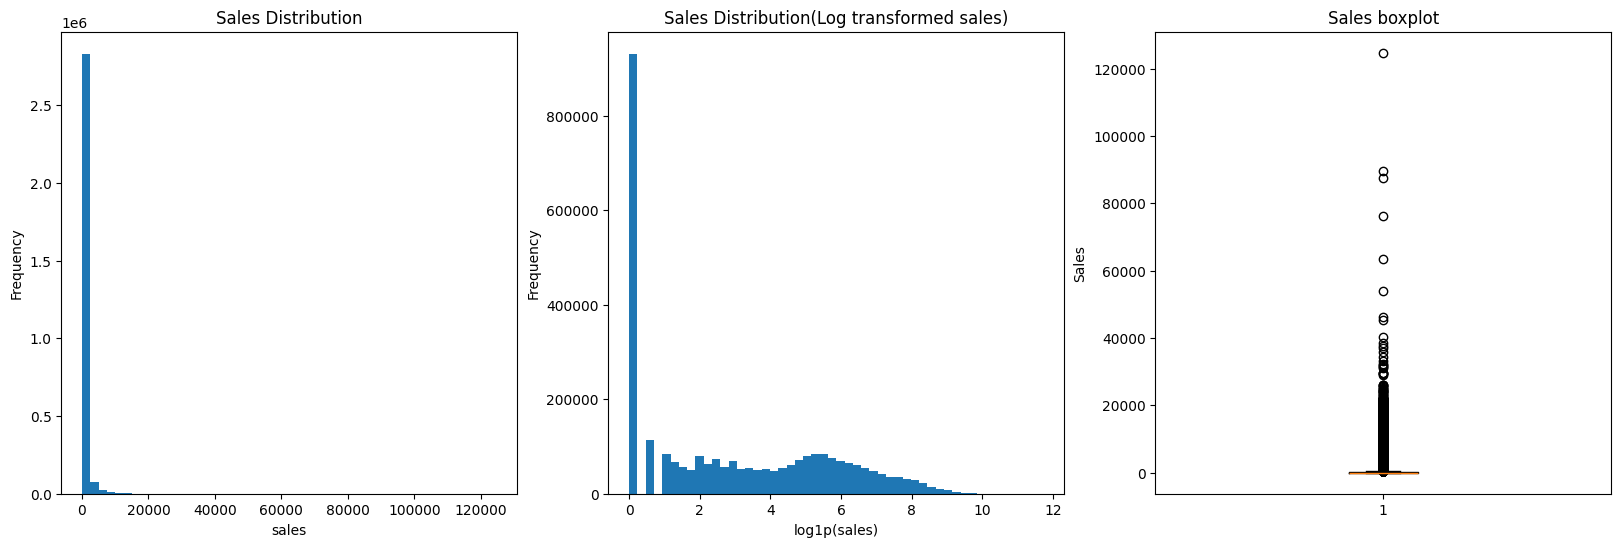

In [138]:
print(y_train.describe().apply(lambda x: format(x, 'f')))

plt.figure(figsize=(20,6))
plt.subplot(1,3,1)
plt.hist(y_train, bins=50)
plt.title("Sales Distribution")
plt.xlabel("sales")
plt.ylabel("Frequency")

plt.subplot(1,3,2)
plt.hist(np.log1p(y_train), bins=50) # We use log1p = ln(1+x), since there are many values for which sales = 0 hence ln(0) will become -inf but log1p(0) = 0
plt.title("Sales Distribution(Log transformed sales)")
plt.xlabel("log1p(sales)")
plt.ylabel("Frequency")

plt.subplot(1,3,3)
plt.title("Sales boxplot")
plt.ylabel("Sales")
plt.boxplot(y_train)
plt.show()

- **From the description of sales data we can see that, the sales value ranges from 0 to 124717.0**
- **25% of the sales are 0, indicating no sales in a particular store on a day for a product category**
- **50% of the sales are <= 10.0**
- **75% of the sales data is <= ~194**
- **And some values are very large like 124717**
- **Hence in the first plot we see that many small values are binned together and we see one large bar with high frequency**
- **And few tiny bars with large values with stretched out x-axis, to accommodate the maximum value**
- **We can see that the sales data is right skewed**
- **To understand the better distribution of sales, we can transform the sales data into log space as indicated in the second plot**

## Applying log transformation to the target variable (sales)
- The target variable sales exhibits a highly right-skewed distribution, as seen from its summary statistics:
    - 25th percentile = 0
    - 50th percentile = 11
    - 75th percentile ≈ 196
    - Maximum value = 124,717

- This indicates that:
    - A large proportion of observations have low or zero sales
    - A small number of observations have extremely high sales (outliers)

- Machine learning models like XGBoost (with squared error loss) are sensitive to large values because errors are squared:
    - Large errors (from high sales values) dominate the loss
    - The model prioritizes fitting these rare extreme values
    - This can lead to poorer performance on the majority of normal observations

- We apply a log transformation:
  - **y = np.log1p(sales)**

This transformation:
    - Compresses large values while keeping smaller values relatively spread out
    - Reduces the effect of extreme outliers
    - Makes the distribution more symmetric (closer to normal)

As a result:
    - The model treats all observations more evenly
    - Training becomes more stable
    - Predictive performance typically improves

In [139]:
y_train_log = np.log1p(y_train)
print("Log transformed sales data(train):",y_train_log[y_train_log != 0].head())

y_val_log = np.log1p(y_val)
print("Log transformed sales data(validation set):",y_val_log[y_val_log != 0].head())

Log transformed sales data(train): 1782    1.098612
3564    1.386294
5346    1.386294
7128    1.791759
8910    1.098612
Name: sales, dtype: float64
Log transformed sales data(validation set): 2943864    1.945910
2945646    1.098612
2947428    1.098612
2949210    1.386294
2950992    2.079442
Name: sales, dtype: float64


## Timeseries split cross validation to find the best model

In [140]:
param_grid = {
    'max_depth': [3, 5, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 5, 10]
}

# TimeSeriesSplit (3 fold CV)
tscv = TimeSeriesSplit(n_splits=3)

# Initializing the model 
xgb_model = xgb.XGBRegressor(
    tree_method='hist', 
    enable_categorical=True,
    n_jobs=-1
)

# Running the random search
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=10,           
    scoring='neg_mean_squared_error', 
    cv=tscv,
    random_state=123,
    verbose=1
)

random_search.fit(X_train, y_train_log)
best_model = random_search.best_estimator_

print("Best Parameters found:", random_search.best_params_)
print("Best Score:", -random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters found: {'subsample': 0.8, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best Score: 0.48836598763519606


## Feature importance of the best model

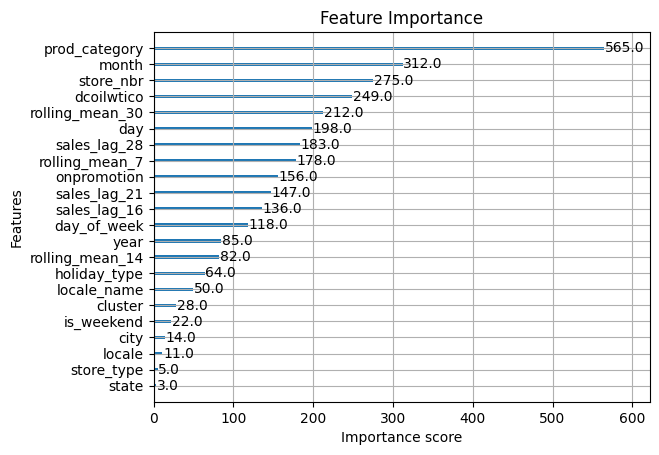

In [141]:
xgb.plot_importance(best_model)
plt.title("Feature Importance")
plt.show()

In [142]:
feature_imp = best_model.feature_importances_
feature_imp_series = pd.Series(feature_imp, index = X_train.columns)
feature_imp_series = feature_imp_series.sort_values(ascending=False)
feature_imp_series

rolling_mean_7     0.491148
sales_lag_21       0.344734
sales_lag_16       0.078434
rolling_mean_30    0.022754
sales_lag_28       0.014755
rolling_mean_14    0.009936
onpromotion        0.005706
prod_category      0.004861
city               0.003936
is_weekend         0.003819
day                0.003782
dcoilwtico         0.003341
year               0.002618
holiday_type       0.002564
month              0.002107
day_of_week        0.002006
store_nbr          0.001933
locale             0.000455
locale_name        0.000380
store_type         0.000349
cluster            0.000275
state              0.000109
dtype: float32

- **We can see that the previous day sales, previous week sales, and other lag varaibles are the some of the important predictors of the future date sales**

## Fitting the best model and predicting on validation data

In [143]:
best_model.fit(X_train, y_train_log)

# Predict on the VALIDATION set
log_preds = best_model.predict(X_val)

# Inverse Transform (Back to actual sales units)
y_preds_val = np.expm1(log_preds)

# Comparing Predictions vs. Truth
validation_comparison = pd.DataFrame({
    'Actual_Sales': y_val,      # This is the real 'sales' from your val_data
    'Predicted_Sales': y_preds_val
}, index=y_val.index)

print(validation_comparison.head())

         Actual_Sales  Predicted_Sales
2943864           6.0         4.989389
2945646           2.0         3.948513
2947428           2.0         3.966446
2949210           3.0         3.858982
2950992           7.0         2.550906


## Root Mean Square Logarithmic error of Validation data

In [144]:
# Calculate the error (RMSLE)
rmsle = np.sqrt(mean_squared_log_error(y_val, y_preds_val))

print(f"Validation RMSLE Score: {rmsle}")

Validation RMSLE Score: 0.4262714042981912


#### **An RMSLE of 0.39 indicates that the model is being off by about ~39% on average across all products in validation data set.**

### Combining the train and validation set for final test prediction

In [145]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train_log, y_val_log])
print(f"Training shapes: X_train={X_train_final.shape}, y_train={y_train_final.shape}")

Training shapes: X_train=(3000888, 22), y_train=(3000888,)


In [146]:
print(X_train_final.columns.tolist())
print(X_test.columns.tolist())

['store_nbr', 'prod_category', 'onpromotion', 'city', 'state', 'store_type', 'cluster', 'dcoilwtico', 'holiday_type', 'locale', 'locale_name', 'year', 'month', 'day', 'day_of_week', 'is_weekend', 'sales_lag_16', 'sales_lag_21', 'sales_lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30']
['store_nbr', 'prod_category', 'onpromotion', 'city', 'state', 'store_type', 'cluster', 'dcoilwtico', 'holiday_type', 'locale', 'locale_name', 'year', 'month', 'day', 'day_of_week', 'is_weekend', 'sales_lag_16', 'sales_lag_21', 'sales_lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30']


In [147]:
best_model.fit(X_train_final, y_train_final)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=-1, num_parallel_tree=None, ...)

In [148]:
final_log_preds = best_model.predict(X_test)
final_preds = np.expm1(final_log_preds)
submission = pd.DataFrame({
    'id': test_with_lags['id'],
    'sales': final_preds
})

submission['sales'] = submission['sales'].clip(lower=0)
submission.to_csv('submission.csv', index=False)
print(submission.shape)
submission

(28512, 2)


,id,sales
0,3000888,3.977899
1782,3002670,3.839918
3564,3004452,4.489125
5346,3006234,5.049017
7128,3008016,3.542309
...,...,...
21251,3022139,1.745313
23033,3023921,1.405891
24815,3025703,1.644051
26597,3027485,1.231258
